# Ford GoBike — Phase 2: EDA & Question Analysis

This notebook completes **Part 2 – Preprocessing, EDA and Question Analysis** for the Ford GoBike dataset.

### Dataset
`preprocessed_fordgobike.csv`

### Contents
- EDA: Duration Distribution
- EDA: Subscriber vs Customer
- Univariate Exploration — Questions 3–9
- Bivariate Exploration — Questions 10–14
- Multivariate Exploration — Questions 15–17
- Conclusions and Limitations


# 1. Import Libraries

In [53]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")


# 2. Load the Preprocessed Dataset

In [78]:
file_name = "preprocessed_fordgobike.csv"


df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (183023, 30)


In [55]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,gender_Female,gender_Male,gender_Other,gender_Unknown,age_group_Adult,age_group_Senior,age_group_Unknown,age_group_Young,duration_min_scaled,age_scaled
0,7200,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,0,1,0,0,1,0,0,0,9.501,0.100
1,7200,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,0,0,0,1,0,0,1,0,9.501,-0.210
2,7200,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,0,1,0,0,1,0,0,0,9.501,1.342
3,7200,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,0,0,1,0,1,0,0,0,9.501,-0.417
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,0,1,0,0,1,0,0,0,1.328,1.135


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183023 entries, 0 to 183022
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183023 non-null  int64  
 1   start_time               183023 non-null  str    
 2   end_time                 183023 non-null  str    
 3   start_station_id         183023 non-null  float64
 4   start_station_name       183023 non-null  str    
 5   start_station_latitude   183023 non-null  float64
 6   start_station_longitude  183023 non-null  float64
 7   end_station_id           183023 non-null  float64
 8   end_station_name         183023 non-null  str    
 9   end_station_latitude     183023 non-null  float64
 10  end_station_longitude    183023 non-null  float64
 11  bike_id                  183023 non-null  int64  
 12  user_type                183023 non-null  str    
 13  member_birth_year        174760 non-null  float64
 14  bike_share_for_

## Quick Data Check

In [79]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())


Missing values:


duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name            0
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name              0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8263
bike_share_for_all_trip       0
duration_min                  0
age                        8263
weekend_flag                  0
user_type_encoded             0
bike_share_encoded            0
gender_Female                 0
gender_Male                   0
gender_Other                  0
gender_Unknown                0
age_group_Adult               0
age_group_Senior              0
age_group_Unknown             0
age_group_Young               0
duration_min_scaled           0
age_scaled                    0
dtype: int64


Duplicated rows: 0

Columns:
['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'bike_share_for_all_trip', 'duration_min', 'age', 'weekend_flag', 'user_type_encoded', 'bike_share_encoded', 'gender_Female', 'gender_Male', 'gender_Other', 'gender_Unknown', 'age_group_Adult', 'age_group_Senior', 'age_group_Unknown', 'age_group_Young', 'duration_min_scaled', 'age_scaled']


# Part 2 — EDA

The project requires three main EDA visualizations:
1. Duration distribution
2. Subscriber vs Customer

These visualizations give a quick overview of trip behavior before answering the detailed questions.


### Interpretation

The number of trips varies across the days of the week. The weekday pattern can be used to understand when the bike-sharing service is used most frequently, while the weekend pattern shows how usage changes outside normal working days.


## EDA 1 — Duration Distribution

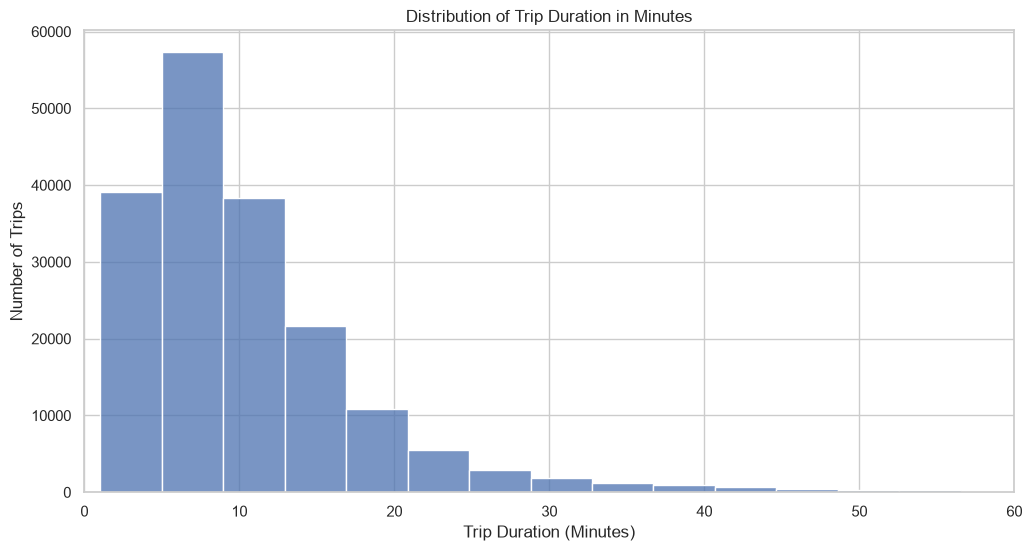

In [59]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration_min', bins=30)

# Focus the visible axis on the range where most trips are concentrated.
# This does not remove longer trips from the dataset.
plt.xlim(0, 60)

plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration in Minutes')

plt.show()


### Interpretation

Most trips have a short duration, while a small number of trips have much longer durations. The visualization focuses on the first 60 minutes to make the main distribution easier to read; longer trips are still present in the dataset.


## EDA 2 — Subscriber vs Customer

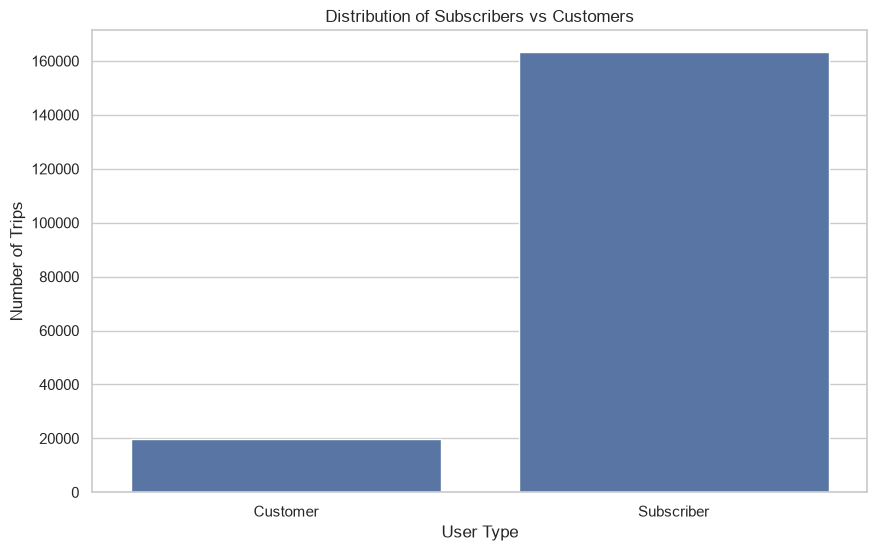

In [60]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='user_type')

plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Subscribers vs Customers')

plt.show()


### Interpretation

Most users are Subscribers, while Customers represent a smaller proportion of the users. This indicates that the service is used mainly by people with a subscription.


# Univariate Exploration

This section answers the individual-variable questions from the original EDA notebook.


## Q3. What is the distribution for User type?

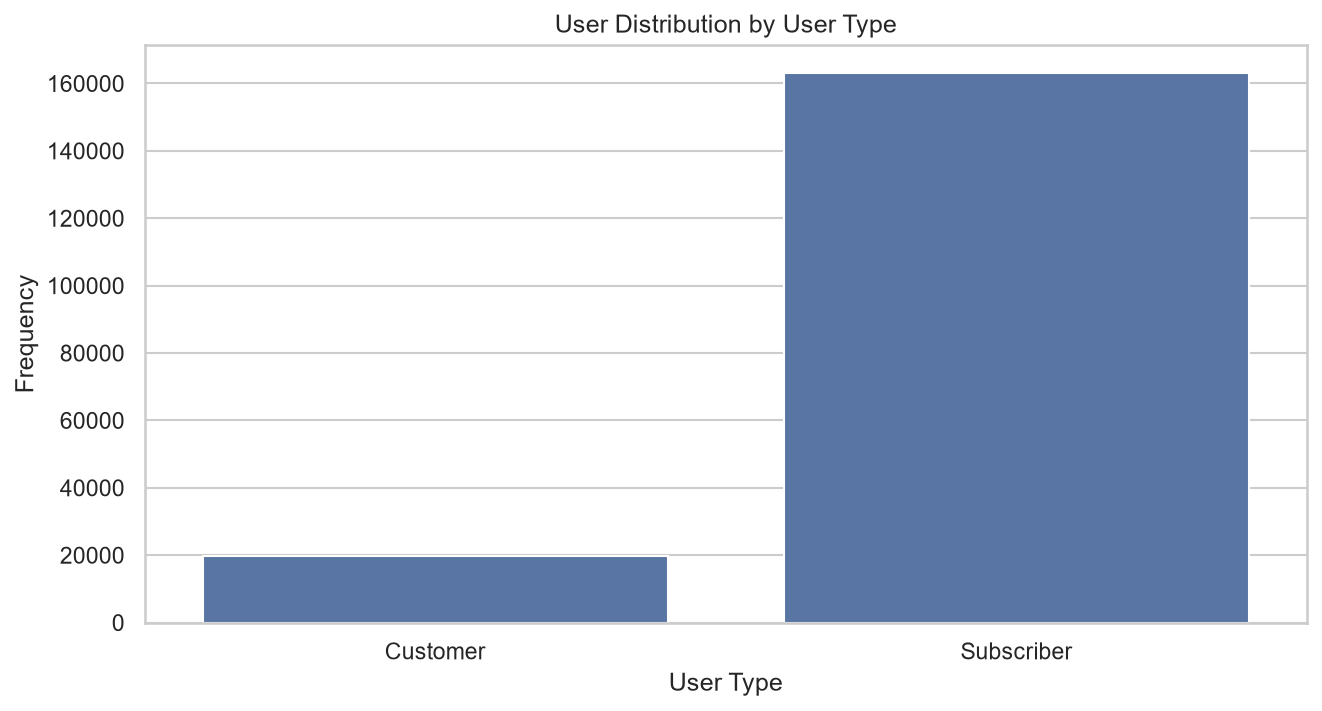

User type counts:


user_type
Subscriber    163231
Customer       19792
Name: count, dtype: int64

In [61]:
plt.figure(figsize=(10, 5), dpi=150)
sns.countplot(data=df, x='user_type')

plt.xlabel('User Type')
plt.ylabel('Frequency')
plt.title("User Distribution by User Type")

plt.show()

user_type_counts = df['user_type'].value_counts()
print("User type counts:")
display(user_type_counts)


### Analysis

The graph shows the distribution of the two user types. **Subscribers are the dominant group**, while **Customers represent a smaller proportion** of the users.


## Q4. What is the distribution for the bike share users on all Trips?

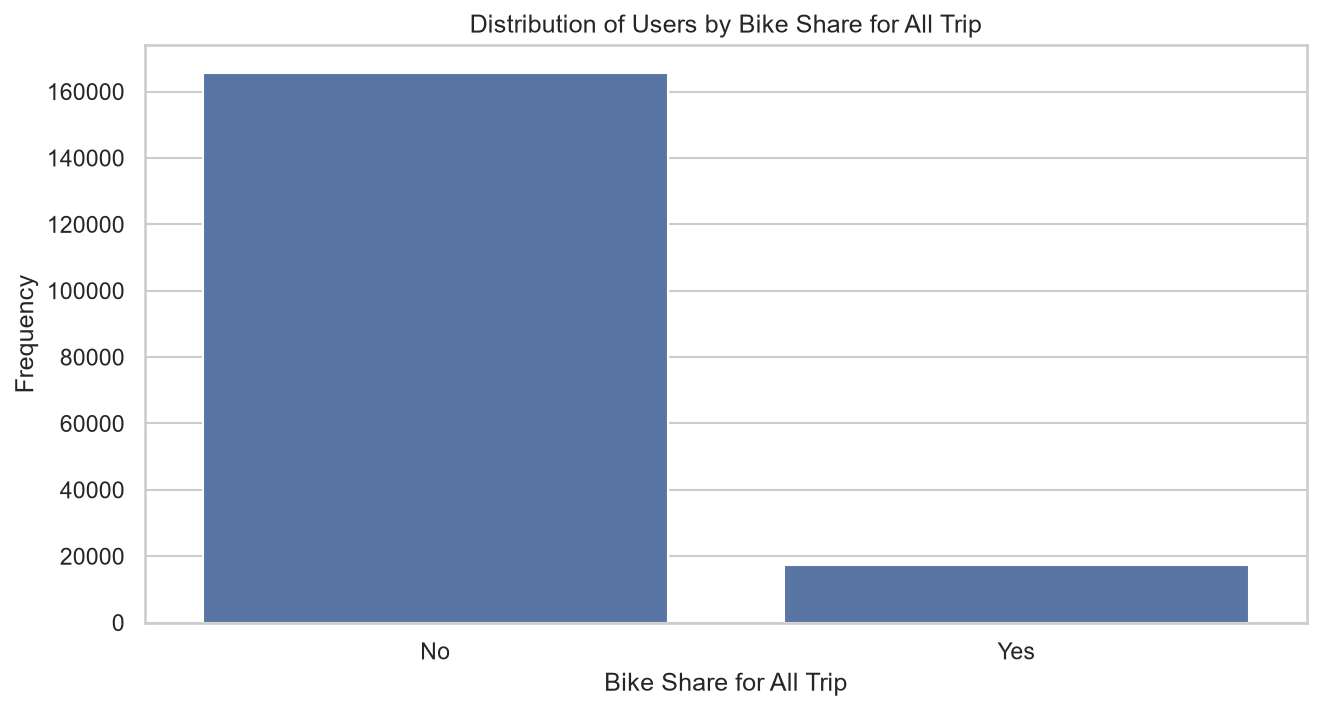

Bike Share for All Trip counts:


bike_share_for_all_trip
No     165724
Yes     17299
Name: count, dtype: int64

In [62]:
plt.figure(figsize=(10, 5), dpi=150)
sns.countplot(data=df, x='bike_share_for_all_trip')

plt.xlabel('Bike Share for All Trip')
plt.ylabel('Frequency')
plt.title("Distribution of Users by Bike Share for All Trip")

plt.show()

bike_share_counts = df['bike_share_for_all_trip'].value_counts()
print("Bike Share for All Trip counts:")
display(bike_share_counts)


### Analysis

Most users are **not** part of the Bike Share for All Trip program, while a smaller proportion of users are enrolled in the program.


## Q5. What is the distribution for users' ages?

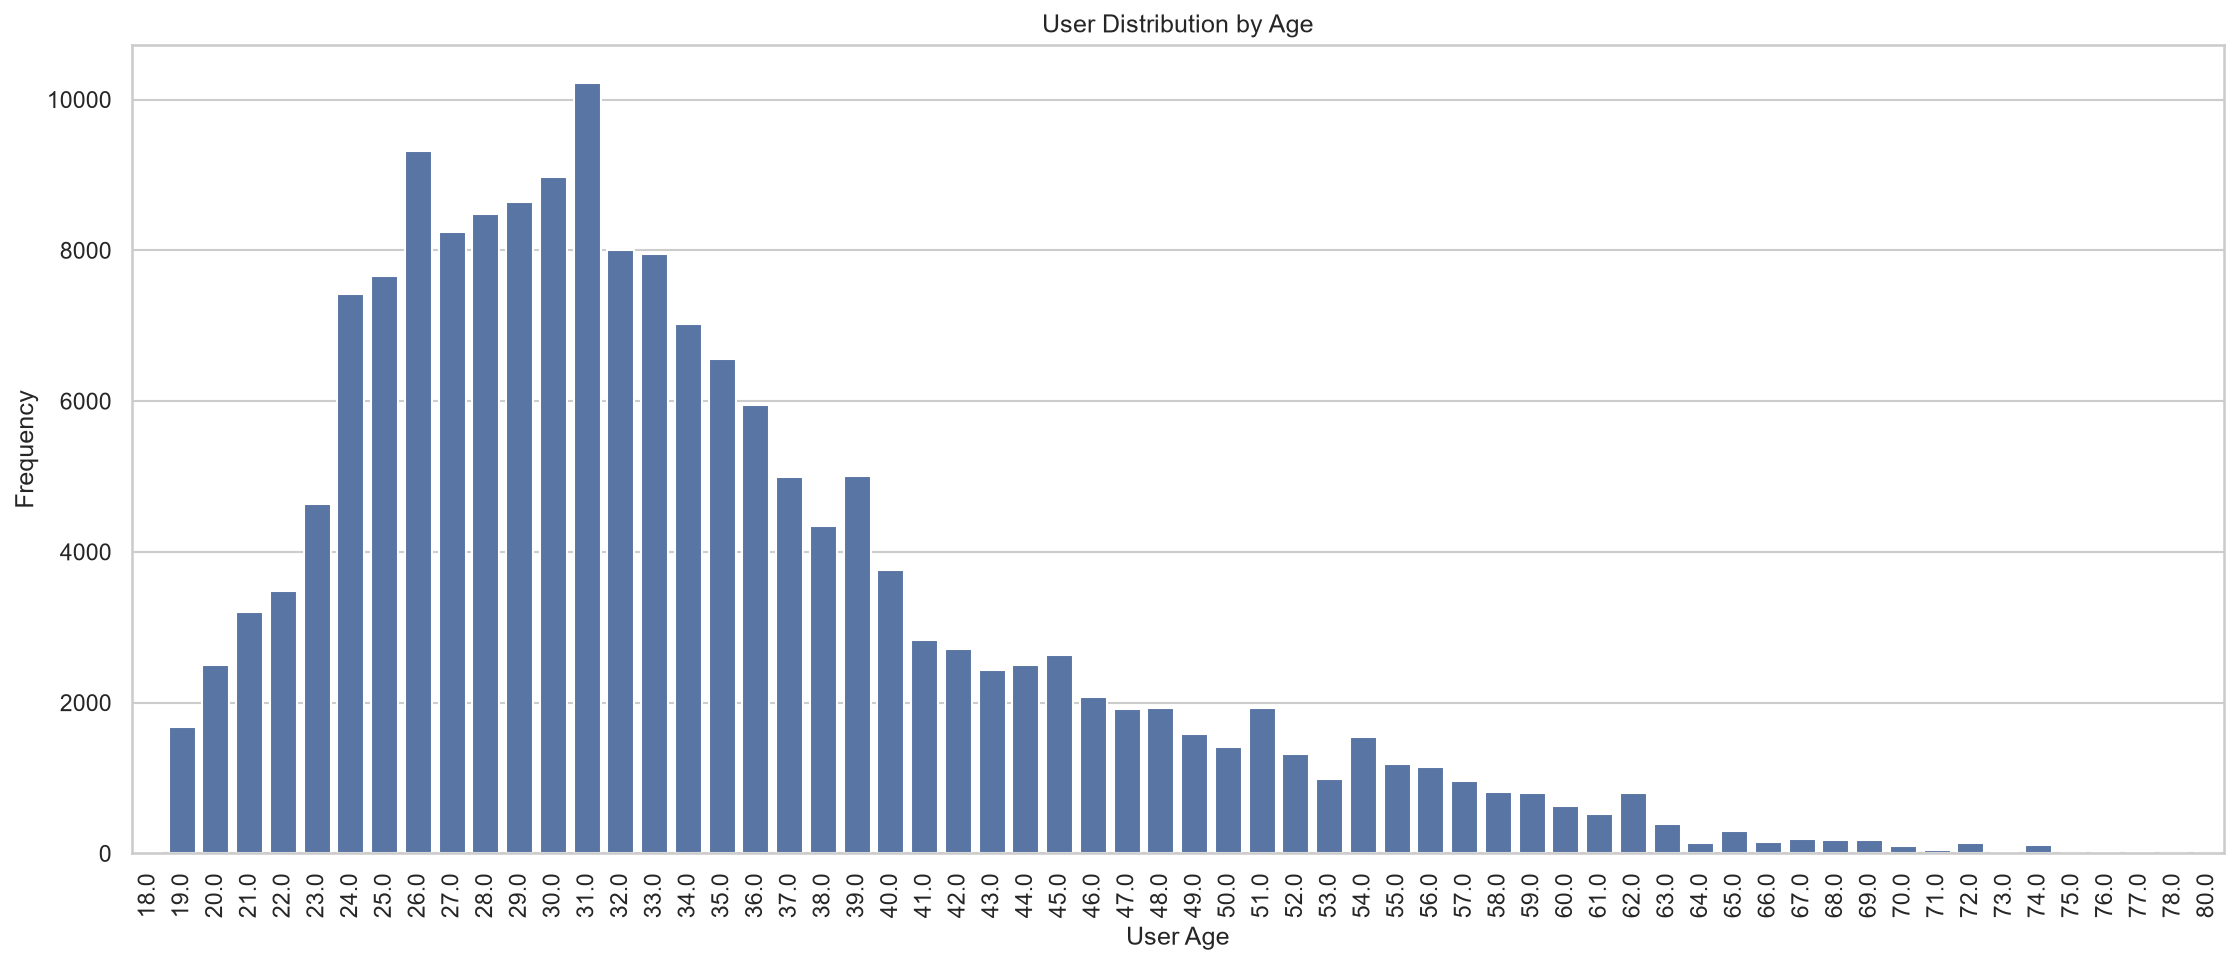

Most common age: 31


In [63]:
plt.figure(figsize=(18, 7), dpi=150)
sns.countplot(data=df, x='age')

plt.xlabel("User Age")
plt.ylabel("Frequency")
plt.title("User Distribution by Age")
plt.xticks(rotation=90)

plt.show()

print("Most common age:", int(df['age'].mode().iloc[0]))


### Analysis

Most users are concentrated in the younger and middle adult age ranges. The most common age is 31 years, while the number of users generally decreases at older ages.


## Q6. Do the users' ages have outlier values?

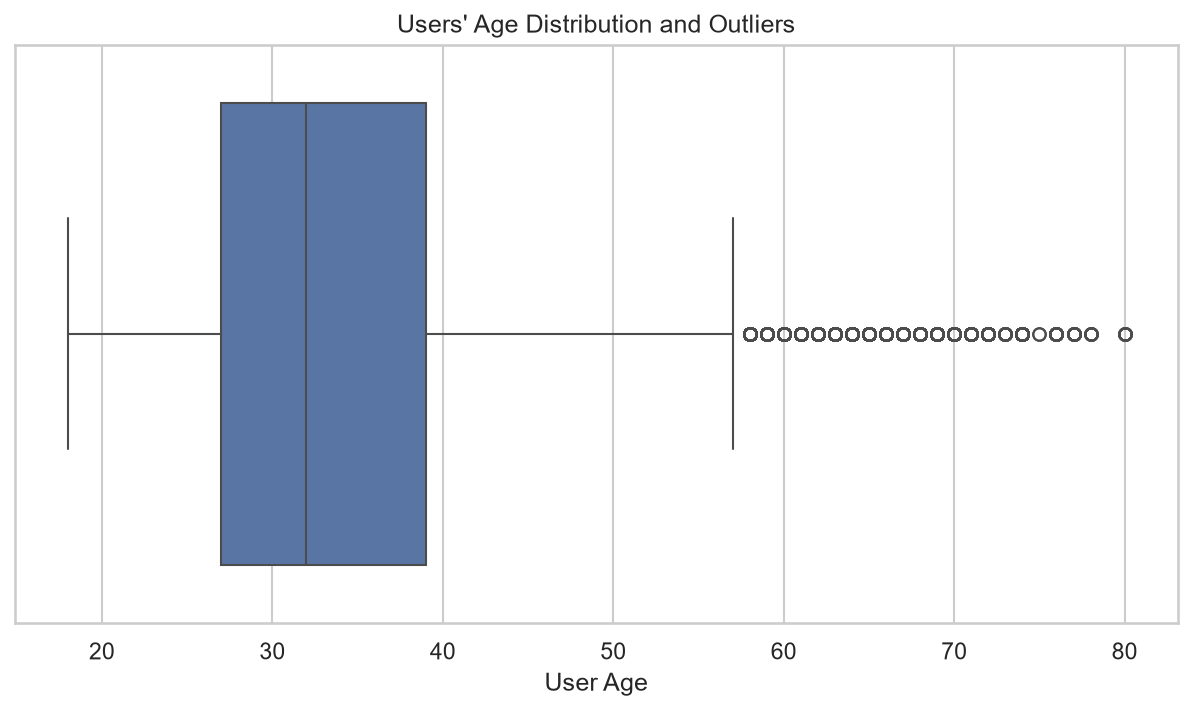

Lower bound: 9.0
Upper bound: 57.0
Number of age outliers: 5589


In [64]:
plt.figure(figsize=(10, 5), dpi=150)
sns.boxplot(data=df, x='age')

plt.xlabel('User Age')
plt.title("Users' Age Distribution and Outliers")

plt.show()

q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of age outliers:", len(outliers))


### Analysis

Yes, the age variable contains outliers. Most users are in the normal adult age range, while some unusually high ages fall outside the main distribution and are detected as outliers by the boxplot/IQR method.


## Q7. What is the distribution for the trip duration in minutes?

Trip duration statistics in minutes:


count    183023.000000
mean         11.211773
std          11.450106
min           1.020000
25%           5.420000
50%           8.570000
75%          13.270000
max         120.000000
Name: duration_min, dtype: float64

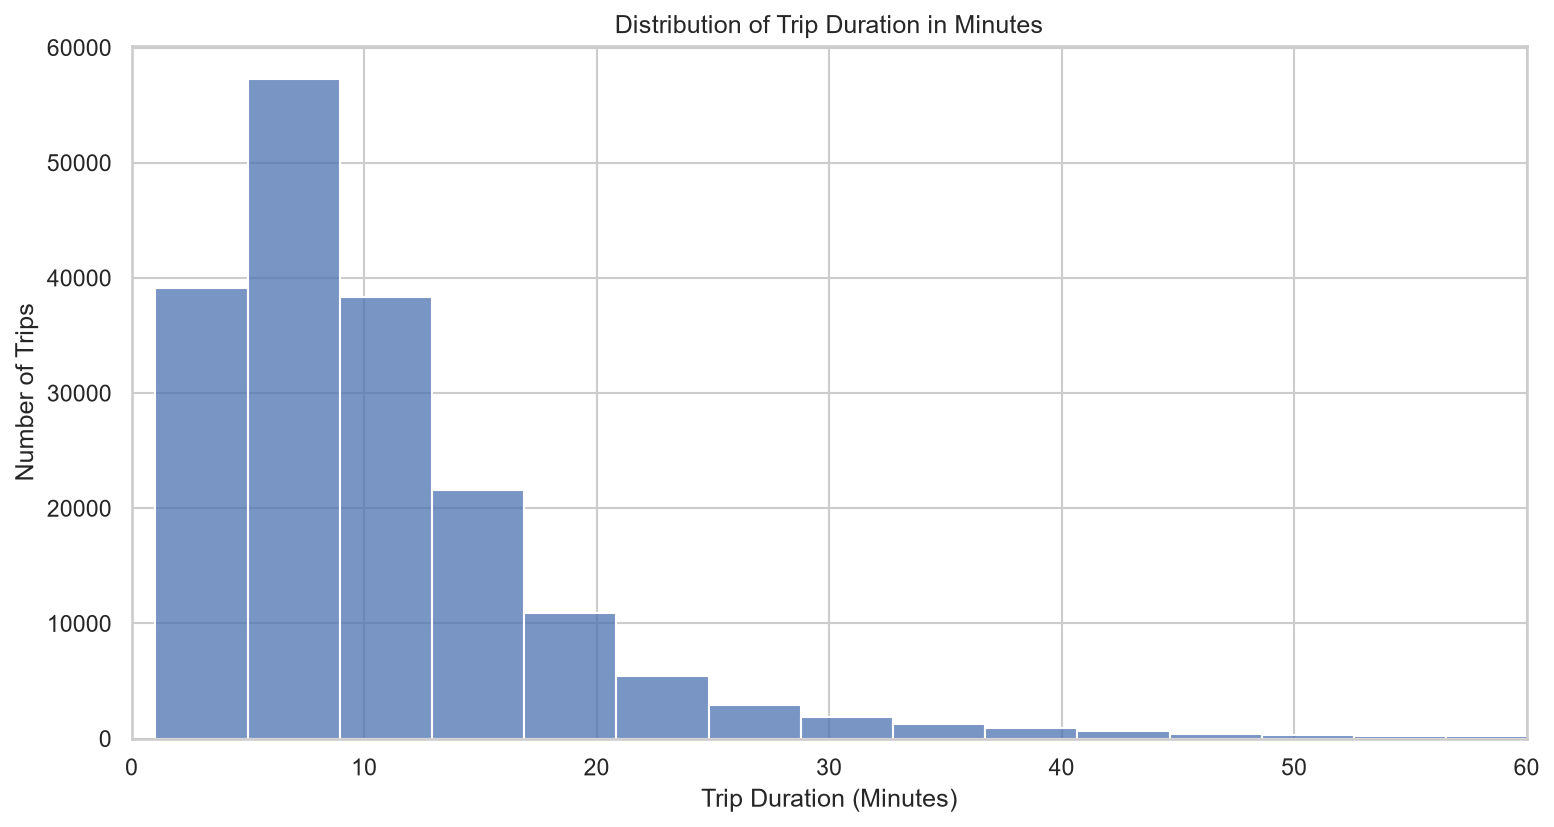

In [65]:
print("Trip duration statistics in minutes:")
display(df['duration_min'].describe())

plt.figure(figsize=(12, 6), dpi=150)
sns.histplot(data=df, x='duration_min', bins=30)

plt.xlim(0, 60)

plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration in Minutes')

plt.show()


### Analysis

Most trips have a short duration. The distribution is **right-skewed**, meaning that a small number of trips have much longer durations than the majority of trips. The graph is limited to the first 60 minutes for clearer visualization without deleting the longer trips.


## Q8. What is the distribution for member_gender?

In [66]:
# Reconstruct member_gender from one-hot encoded columns
conditions = [
    df['gender_Female'] == 1,
    df['gender_Male'] == 1,
    df['gender_Other'] == 1,
    df['gender_Unknown'] == 1
]

choices = ['Female', 'Male', 'Other', 'Unknown']

df['member_gender'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

df['member_gender'].value_counts()

member_gender
Male       130345
Female      40771
Unknown      8263
Other        3644
Name: count, dtype: int64

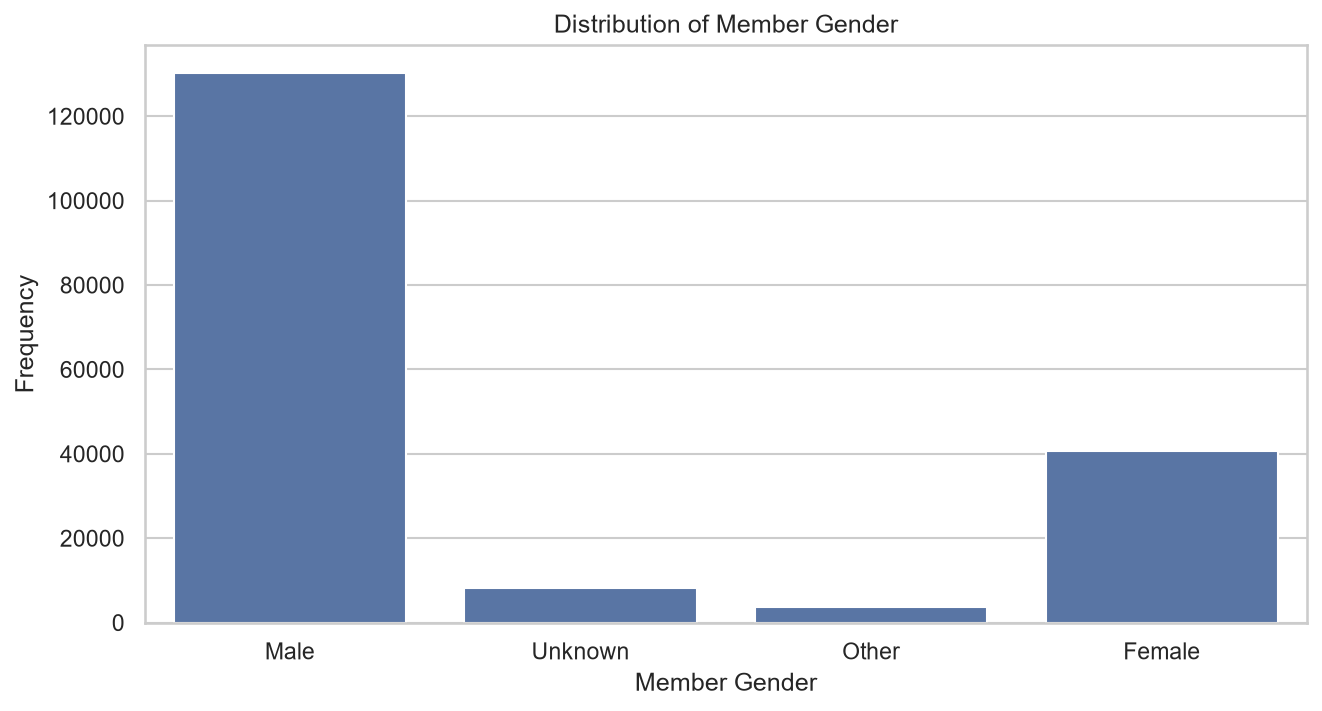

Gender counts:


member_gender
Male       130345
Female      40771
Unknown      8263
Other        3644
Name: count, dtype: int64

In [67]:
plt.figure(figsize=(10, 5), dpi=150)
sns.countplot(data=df, x='member_gender')
plt.xlabel('Member Gender')
plt.ylabel('Frequency')
plt.title('Distribution of Member Gender')

plt.show()

print("Gender counts:")
display(df['member_gender'].value_counts())


### Analysis

Male users represent the largest group, followed by Female users. Unknown and Other represent smaller groups, with Other being the smallest.

## Q9. What is the distribution for the trip duration in Hours?

In [68]:
# Convert trip duration from minutes to hours

df['duration_hrs'] = df['duration_min'] / 60

Trip duration statistics in hours:


count    183023.000000
mean          0.186863
std           0.190835
min           0.017000
25%           0.090333
50%           0.142833
75%           0.221167
max           2.000000
Name: duration_hrs, dtype: float64

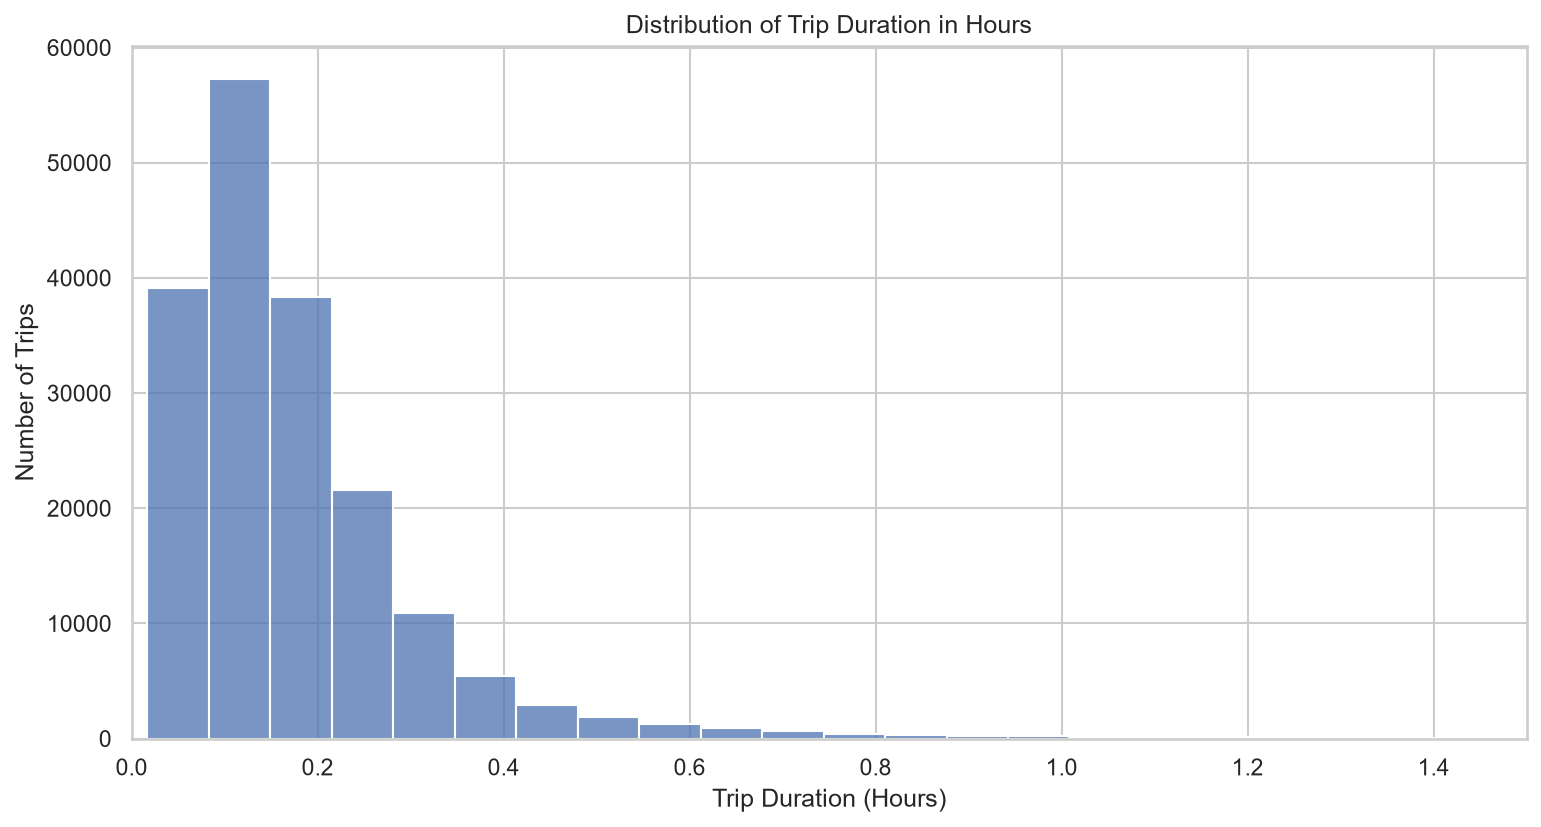

In [69]:
print("Trip duration statistics in hours:")
display(df['duration_hrs'].describe())

plt.figure(figsize=(12, 6), dpi=150)
sns.histplot(data=df, x='duration_hrs', bins=30)

plt.xlim(0, 1.5)

plt.xlabel('Trip Duration (Hours)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration in Hours')

plt.show()


### Analysis

Most trips have a short duration. Only a small number of trips continue for much longer periods. The graph focuses on the first **1.5 hours** so the main distribution is easier to see, while longer trips remain in the dataset.


## Summary of the Univariate Exploration

- Subscribers are the dominant user type.
- Most users are not enrolled in the Bike Share for All Trip program.
- Users are mainly concentrated in the adult age ranges.
- Age contains outlier values.
- Trip duration is strongly concentrated in the shorter-duration range and is right-skewed.
- Male users represent the largest gender group.


# Bivariate Exploration

This section investigates relationships between two variables.


## Q10. What is the average duration of trip for the categories of user type?

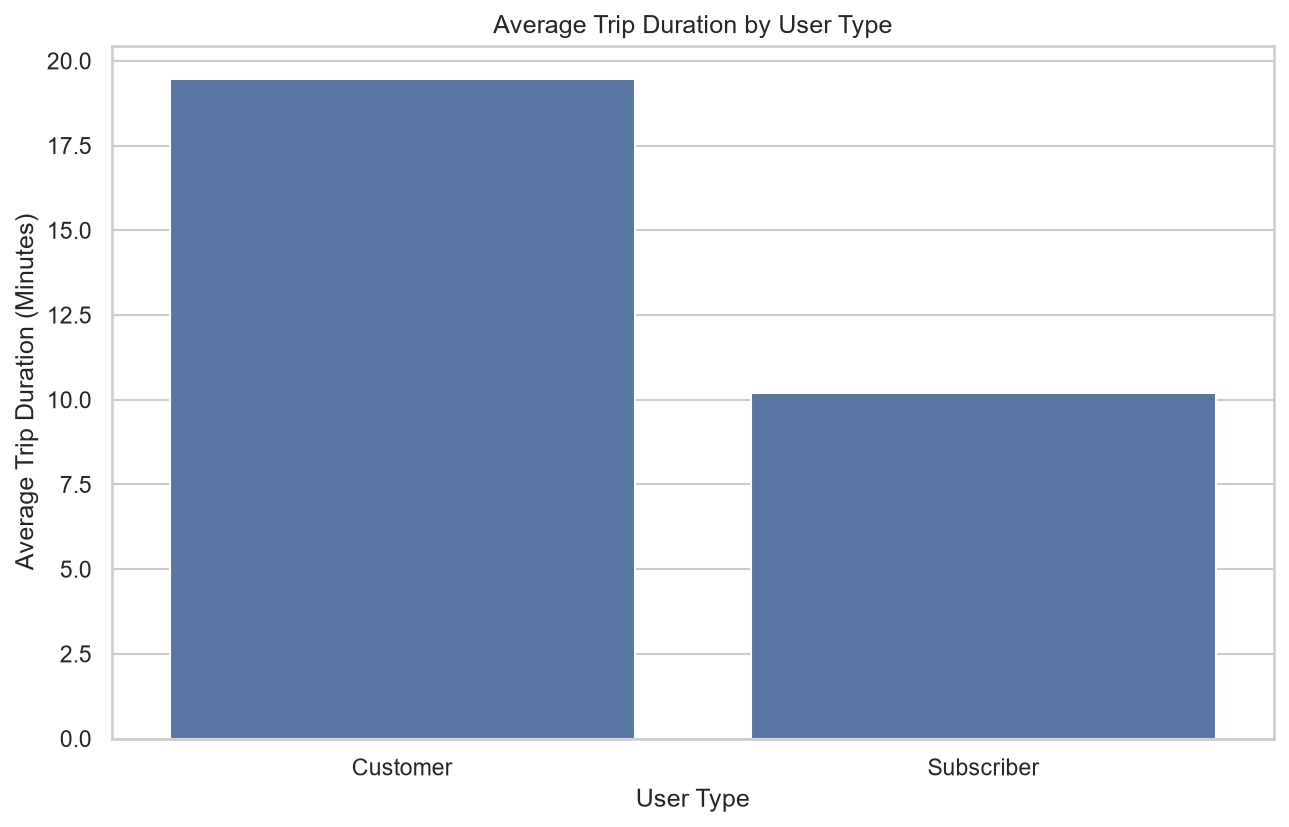

,Average Duration (Minutes)
user_type,
Customer,19.477198
Subscriber,10.209578


In [70]:
avg_duration_by_user = (
    df.groupby('user_type', observed=False)['duration_min']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6), dpi=150)
sns.barplot(
    x=avg_duration_by_user.index,
    y=avg_duration_by_user.values
)

plt.xlabel('User Type')
plt.ylabel('Average Trip Duration (Minutes)')
plt.title('Average Trip Duration by User Type')

plt.show()

display(avg_duration_by_user.rename('Average Duration (Minutes)').to_frame())


### Analysis

Customers have a higher average trip duration than Subscribers. Customers spend about 19.5 minutes per trip on average, compared with about 10.2 minutes for Subscribers.

## Q11. How long is the duration of the trip for each gender in minutes?

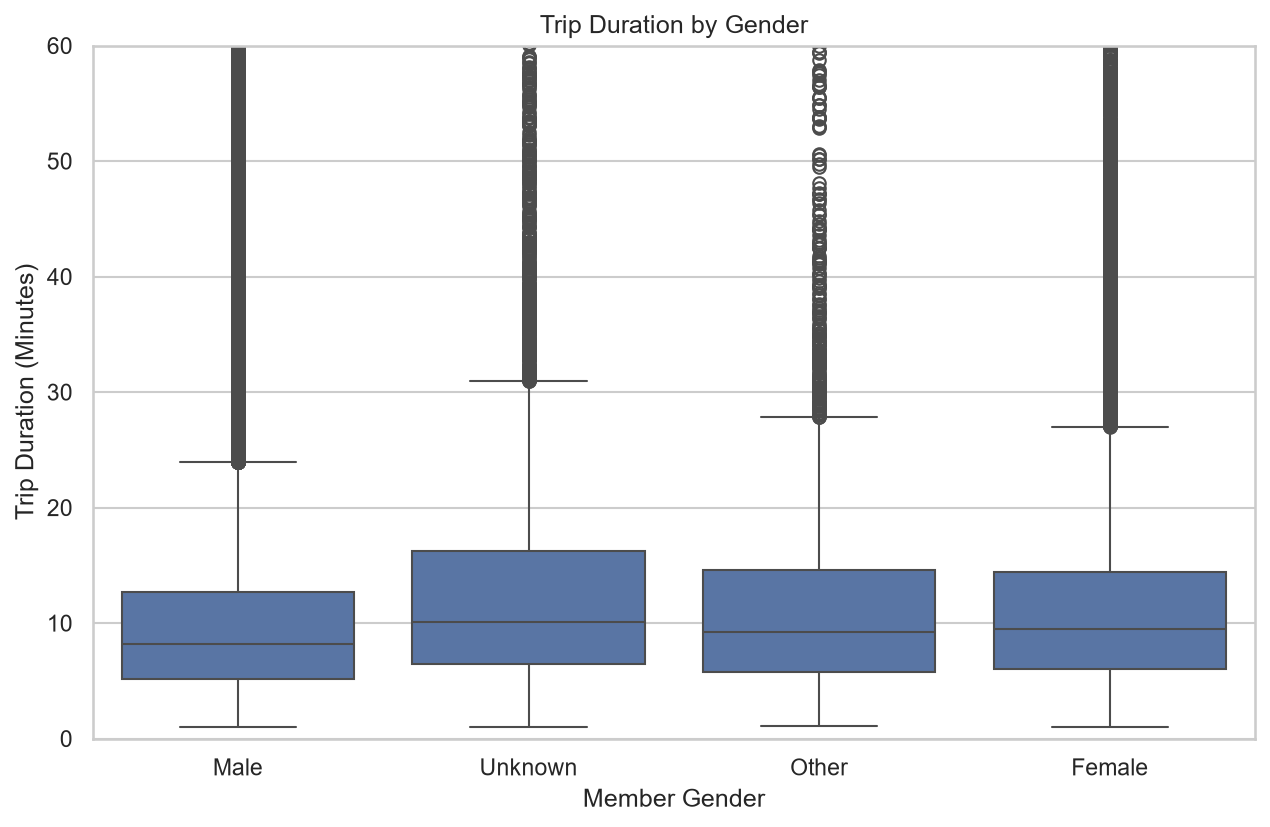

,Average Duration (Minutes)
member_gender,
Unknown,15.743435
Other,13.187489
Female,12.076561
Male,10.598763


In [71]:
plt.figure(figsize=(10, 6), dpi=150)
sns.boxplot(data=df, x='member_gender', y='duration_min')

plt.ylim(0, 60)

plt.xlabel('Member Gender')
plt.ylabel('Trip Duration (Minutes)')
plt.title('Trip Duration by Gender')

plt.show()

display(
    df.groupby('member_gender', observed=False)['duration_min']
      .mean()
      .sort_values(ascending=False)
      .rename('Average Duration (Minutes)')
      .to_frame()
)


### Analysis

Average trip duration is highest for users with Unknown gender, followed by Other, Female, and Male users. Male users have the shortest average trip duration among the reported gender groups.


## Q12. How long is the duration of the trip for each user_type in minutes?

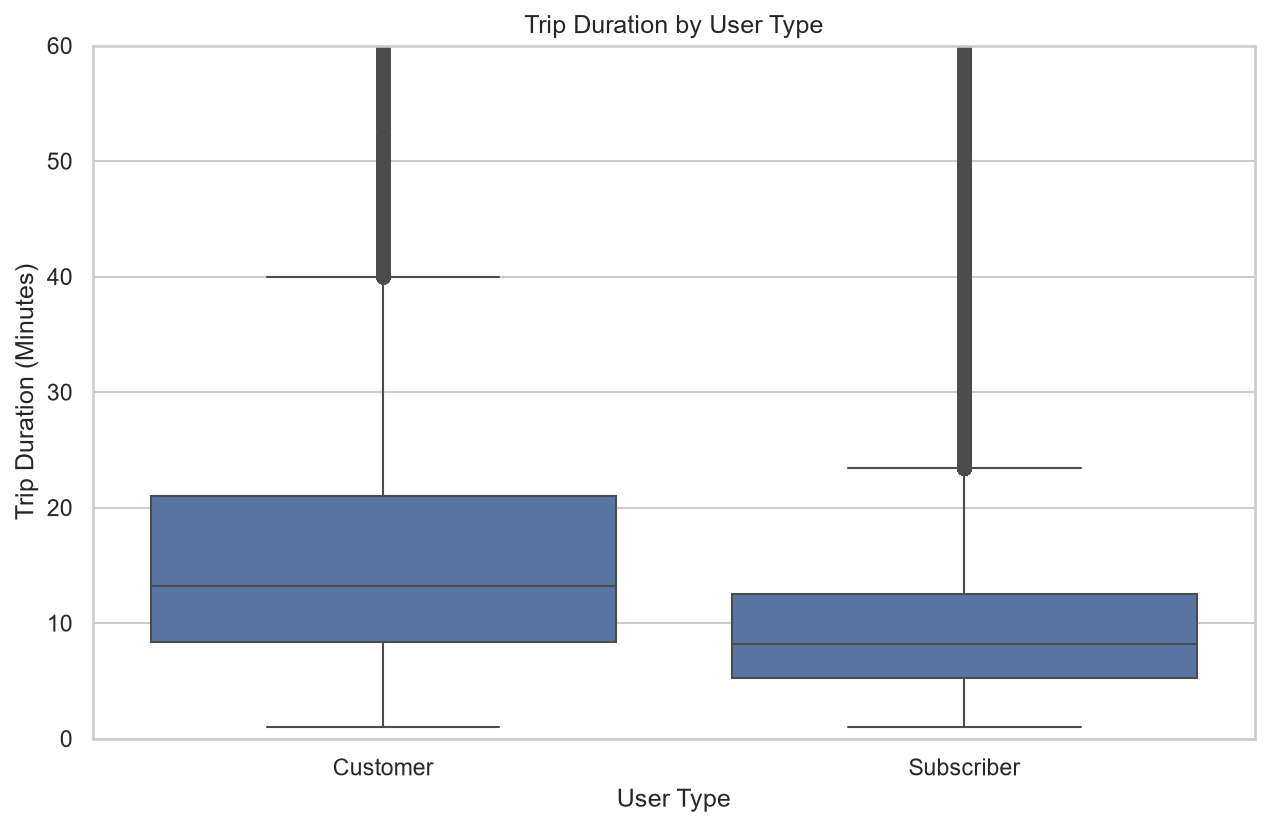

,mean,median,min,max
user_type,,,,
Customer,19.477198,13.19,1.03,120.0
Subscriber,10.209578,8.18,1.02,120.0


In [72]:
plt.figure(figsize=(10, 6), dpi=150)
sns.boxplot(data=df, x='user_type', y='duration_min')

plt.ylim(0, 60)

plt.xlabel('User Type')
plt.ylabel('Trip Duration (Minutes)')
plt.title('Trip Duration by User Type')

plt.show()

display(
    df.groupby('user_type', observed=False)['duration_min']
      .agg(['mean', 'median', 'min', 'max'])
      .sort_values('mean', ascending=False)
)


### Analysis

Customers generally have longer trips than Subscribers. The average trip duration is about 19.5 minutes for Customers versus 10.2 minutes for Subscribers, and the median is also higher for Customers (13.19 vs. 8.18 minutes)


## Q13. How is the user distribution depending on their Age and user_type?

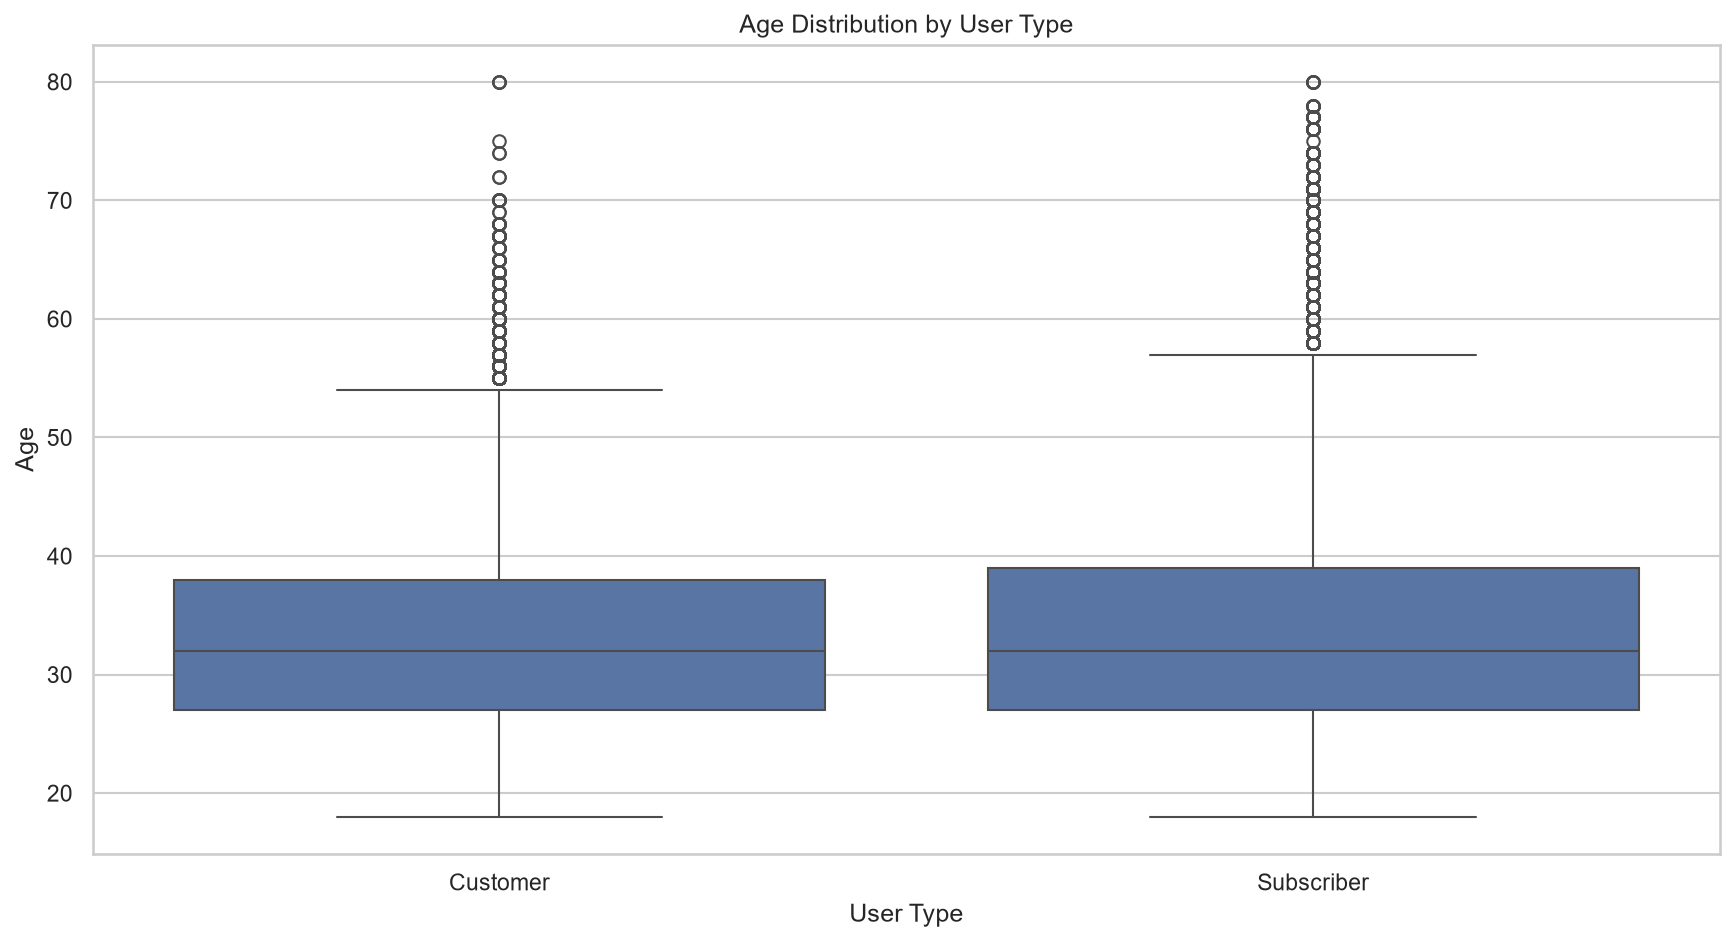

,mean,median,min,max
user_type,,,,
Customer,33.608504,32.0,18.0,80.0
Subscriber,34.179301,32.0,18.0,80.0


In [73]:
plt.figure(figsize=(14, 7), dpi=150)
sns.boxplot(data=df, x='user_type', y='age')

plt.xlabel('User Type')
plt.ylabel('Age')
plt.title('Age Distribution by User Type')

plt.show()

display(
    df.groupby('user_type', observed=False)['age']
      .agg(['mean', 'median', 'min', 'max'])
)


### Analysis

The age distributions of Customers and Subscribers are quite similar overall. Both groups have a median age of 32 years, with very similar mean ages.

## Q14. How is the user distribution depending on their Age and member_gender?

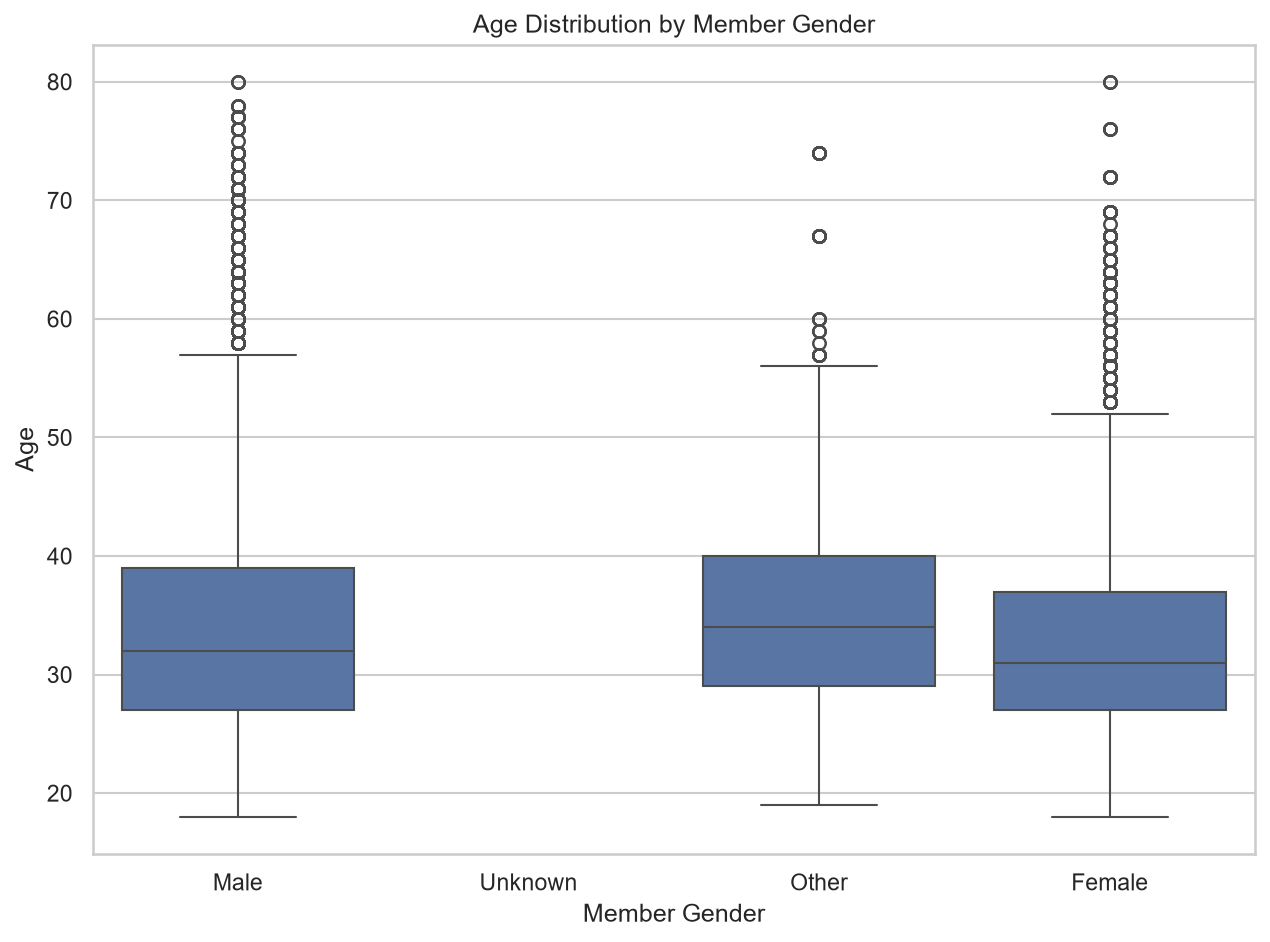

,mean,median,min,max
member_gender,,,,
Female,33.168355,31.0,18.0,80.0
Male,34.376355,32.0,18.0,80.0
Other,35.848244,34.0,19.0,74.0
Unknown,NaN,NaN,NaN,NaN


In [74]:
plt.figure(figsize=(10, 7), dpi=150)
sns.boxplot(data=df, x='member_gender', y='age')

plt.xlabel('Member Gender')
plt.ylabel('Age')
plt.title('Age Distribution by Member Gender')

plt.show()

display(
    df.groupby('member_gender', observed=False)['age']
      .agg(['mean', 'median', 'min', 'max'])
)


### Analysis

The age distributions are fairly similar across Female and Male users, while Other users have a slightly higher median age. The Unknown gender group cannot be compared by age because its age values are missing.

# Multivariate Exploration

This section investigates relationships among multiple numeric variables using correlation analysis.


## Q15. What is the correlation between each variable in the dataset?

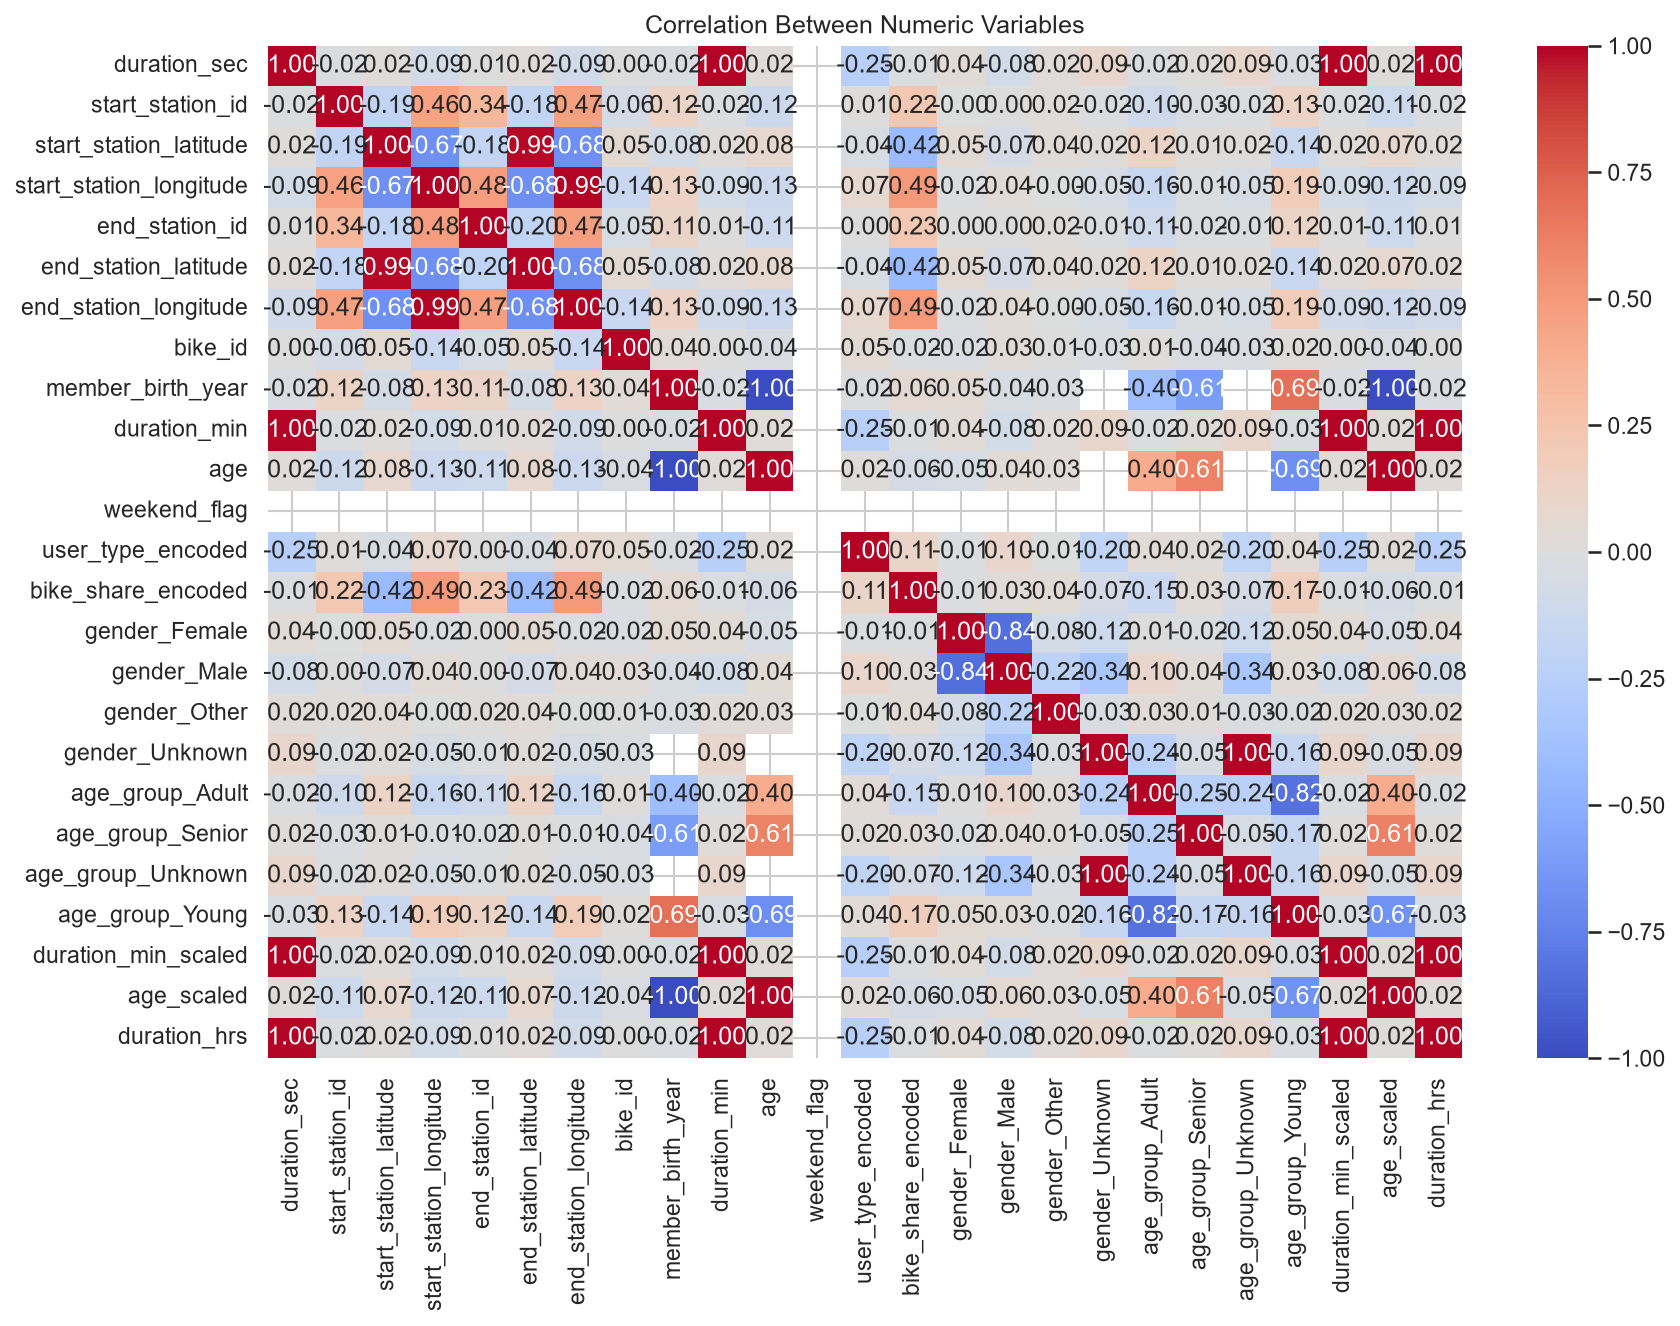

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,duration_min,...,gender_Male,gender_Other,gender_Unknown,age_group_Adult,age_group_Senior,age_group_Unknown,age_group_Young,duration_min_scaled,age_scaled,duration_hrs
duration_sec,1.000000,-0.015783,0.021721,-0.085363,0.005174,0.023442,-0.087137,0.001405,-0.023484,1.000000,...,-0.084215,0.024594,0.086059,-0.021447,0.022393,0.086059,-0.025070,1.000000,0.017743,1.000000
start_station_id,-0.015783,1.000000,-0.191116,0.459374,0.336325,-0.179924,0.466903,-0.064621,0.117777,-0.015783,...,0.004082,0.018252,-0.016992,-0.103979,-0.026455,-0.016992,0.127225,-0.015783,-0.114044,-0.015783
start_station_latitude,0.021721,-0.191116,1.000000,-0.672949,-0.179838,0.989828,-0.678412,0.049699,-0.075736,0.021721,...,-0.066108,0.039442,0.018428,0.121271,0.009976,0.018428,-0.138414,0.021722,0.074172,0.021721
start_station_longitude,-0.085363,0.459374,-0.672949,1.000000,0.479690,-0.677590,0.992324,-0.142062,0.126588,-0.085363,...,0.043311,-0.004289,-0.053212,-0.155975,-0.012981,-0.053212,0.190882,-0.085364,-0.122543,-0.085363
end_station_id,0.005174,0.336325,-0.179838,0.479690,1.000000,-0.198100,0.469081,-0.054637,0.113852,0.005173,...,0.000816,0.018379,-0.014737,-0.106067,-0.018352,-0.014737,0.124781,0.005173,-0.110270,0.005173
end_station_latitude,0.023442,-0.179924,0.989828,-0.677590,-0.198100,1.000000,-0.679986,0.048937,-0.075920,0.023443,...,-0.066042,0.038997,0.018908,0.121243,0.010010,0.018908,-0.138608,0.023443,0.074333,0.023443
end_station_longitude,-0.087137,0.466903,-0.678412,0.992324,0.469081,-0.679986,1.000000,-0.143812,0.127526,-0.087137,...,0.042790,-0.004674,-0.053822,-0.155824,-0.014078,-0.053822,0.191481,-0.087138,-0.123434,-0.087137
bike_id,0.001405,-0.064621,0.049699,-0.142062,-0.054637,0.048937,-0.143812,1.000000,0.038087,0.001405,...,0.032462,0.005985,-0.025869,0.011101,-0.035448,-0.025869,0.015585,0.001405,-0.035866,0.001405
member_birth_year,-0.023484,0.117777,-0.075736,0.126588,0.113852,-0.075920,0.127526,0.038087,1.000000,-0.023485,...,-0.043554,-0.025455,NaN,-0.400844,-0.608692,NaN,0.685919,-0.023485,-1.000000,-0.023485
duration_min,1.000000,-0.015783,0.021721,-0.085363,0.005173,0.023443,-0.087137,0.001405,-0.023485,1.000000,...,-0.084216,0.024593,0.086059,-0.021447,0.022393,0.086059,-0.025071,1.000000,0.017743,1.000000


In [75]:
numeric_df = df.select_dtypes(include=np.number)

corr_all = numeric_df.corr()

plt.figure(figsize=(12, 9), dpi=150)
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

display(corr_all)


### Analysis

The correlation matrix shows the strength and direction of relationships between the numeric variables. Values close to **+1** indicate a strong positive relationship, values close to **-1** indicate a strong negative relationship, and values close to **0** indicate little or no linear relationship.

The duration variables (`duration_sec`, `duration_min`, and `duration_hrs`) are expected to be highly correlated because they represent the same trip duration in different units.


## Q16. What is the correlation between specific numeric variables in the dataset?

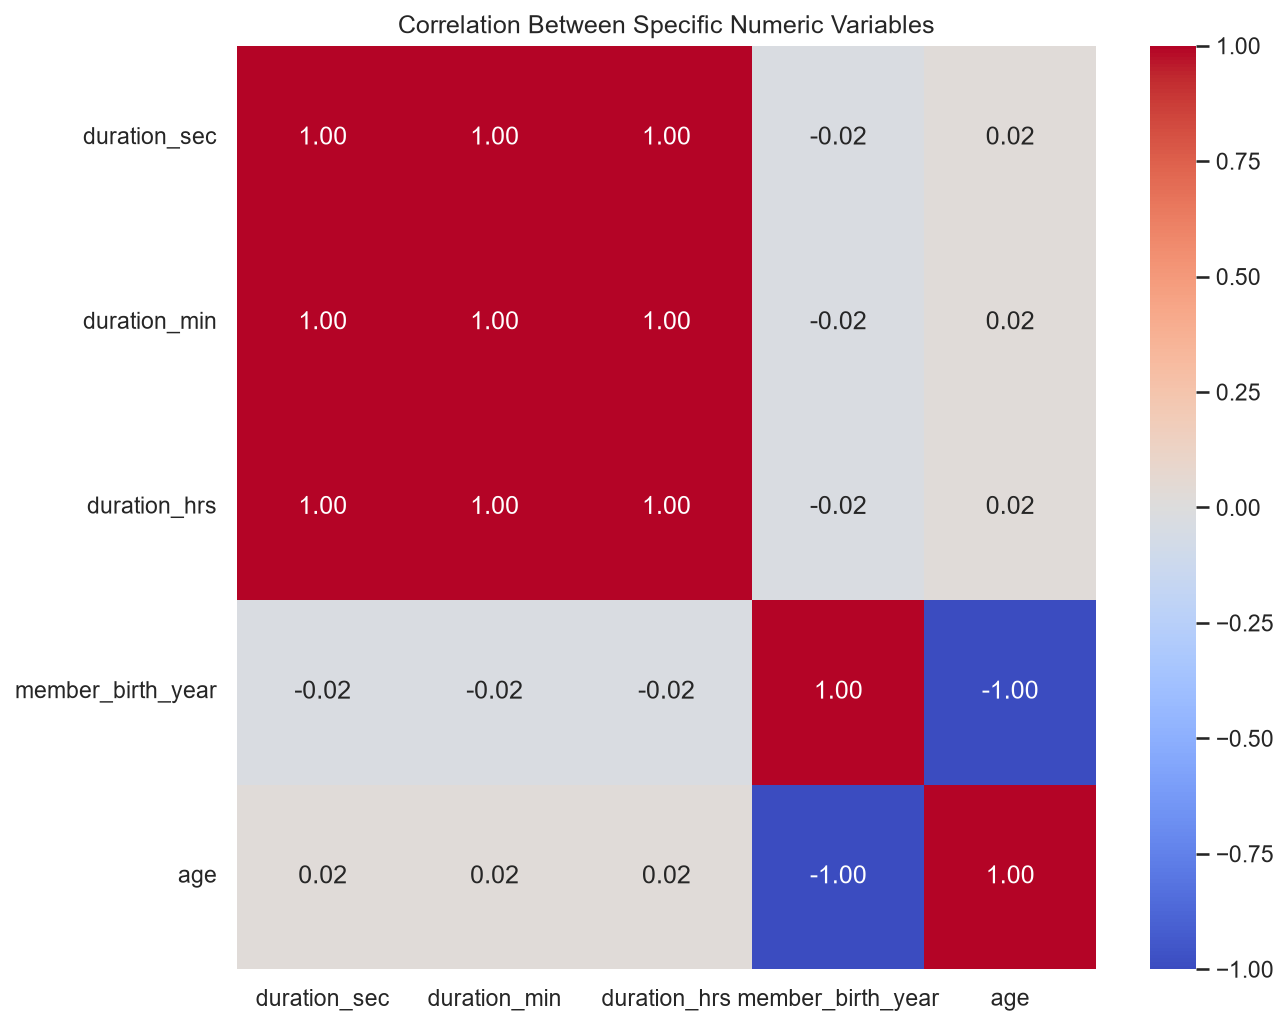

,duration_sec,duration_min,duration_hrs,member_birth_year,age
duration_sec,1.000000,1.000000,1.000000,-0.023484,0.023484
duration_min,1.000000,1.000000,1.000000,-0.023485,0.023485
duration_hrs,1.000000,1.000000,1.000000,-0.023485,0.023485
member_birth_year,-0.023484,-0.023485,-0.023485,1.000000,-1.000000
age,0.023484,0.023485,0.023485,-1.000000,1.000000


In [76]:
# Focus on meaningful numeric variables for the analysis
candidate_cols = [
    'duration_sec',
    'duration_min',
    'duration_hrs',
    'member_birth_year',
    'age'
]

selected_cols = [col for col in candidate_cols if col in df.columns]

specific_corr = df[selected_cols].corr()

plt.figure(figsize=(9, 7), dpi=150)
sns.heatmap(specific_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Between Specific Numeric Variables')
plt.tight_layout()
plt.show()

display(specific_corr)


### Analysis

The selected numeric variables make the most meaningful relationships easier to inspect. The three duration variables have very strong correlations because they are mathematical conversions of the same measurement. Age and birth year show a strong negative relationship because a newer birth year corresponds to a younger age.


## Q17. What is the correlation between data-stat variables in the dataset?

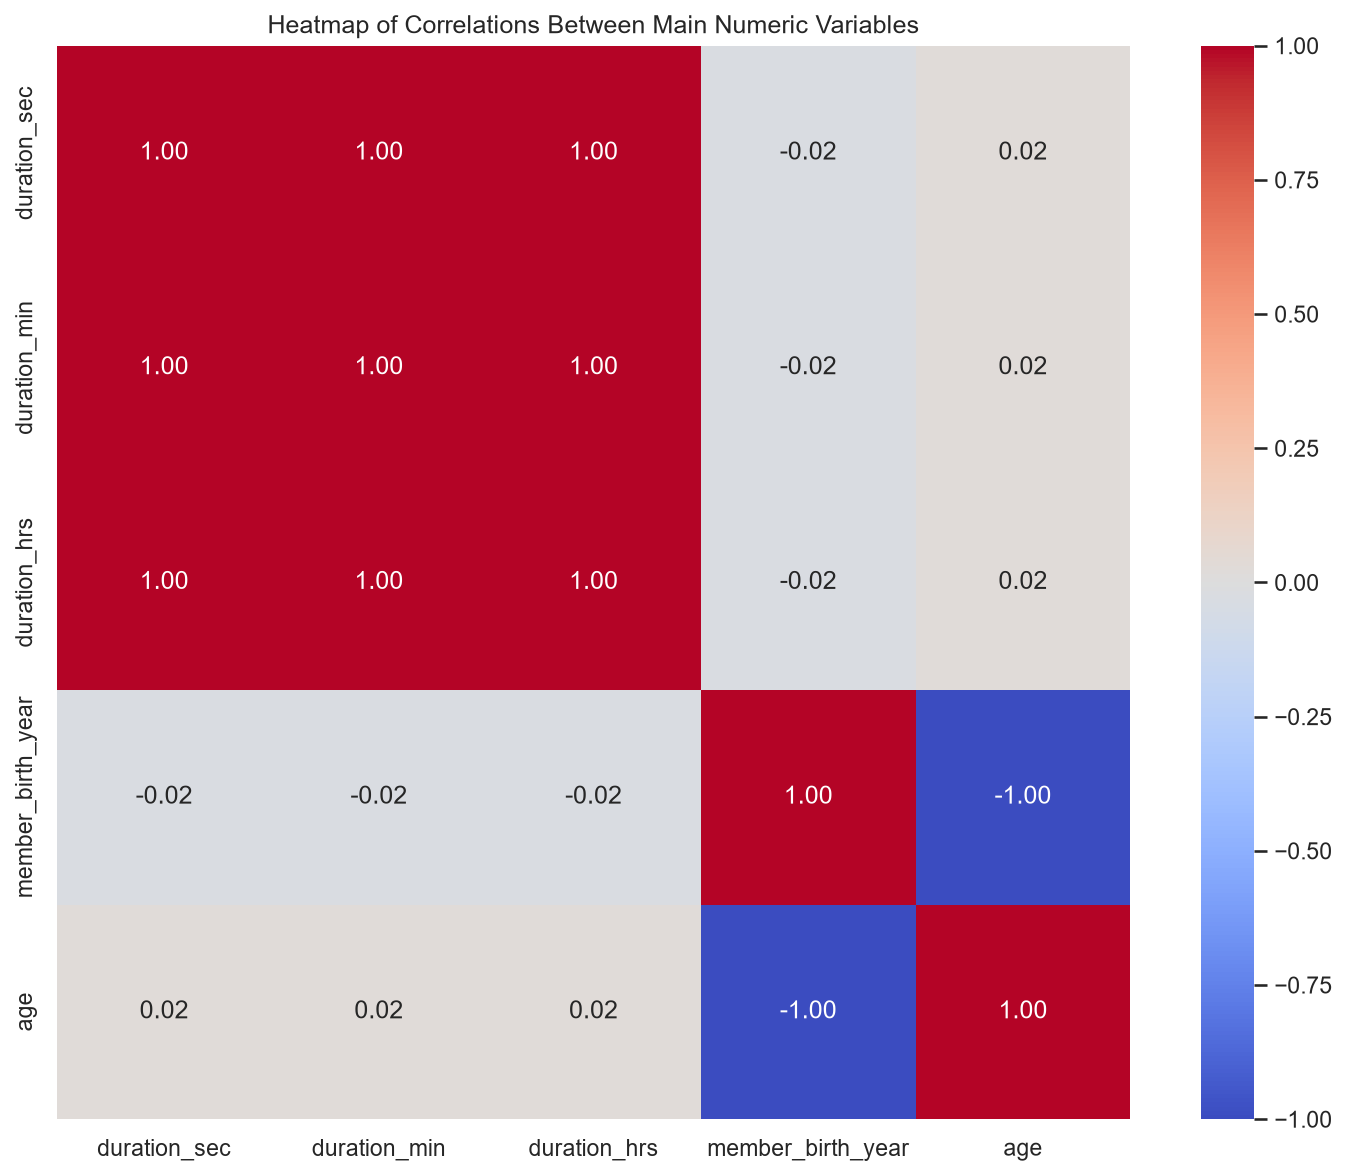

In [77]:
# A focused heatmap for the main statistical variables used in the analysis
heatmap_cols = [
    'duration_sec',
    'duration_min',
    'duration_hrs',
    'member_birth_year',
    'age'
]

heatmap_cols = [col for col in heatmap_cols if col in df.columns]

plt.figure(figsize=(10, 8), dpi=150)
sns.heatmap(
    df[heatmap_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Heatmap of Correlations Between Main Numeric Variables')
plt.tight_layout()
plt.show()


### Analysis

The heatmap presents the same important statistical relationships in a clear visual form. The strongest relationships are between the duration variables and between `member_birth_year` and `age`. The duration variables are strongly related because they measure the same trip duration in seconds, minutes, and hours.


# Overall Findings

### Main relationships observed

- **User type:** Subscribers are the main user group.
- **Bike Share for All Trip:** Most users are not enrolled in the program.
- **Age:** Users are concentrated in the adult age range, with some high-age outliers.
- **Duration:** Most trips are short and the distribution is right-skewed.
- **Gender:** Male users represent the largest group.
- **User type vs duration:** Trip duration can be compared directly between Subscribers and Customers.
- **Age vs user type:** The age distribution differs between the user categories.
- **Age vs gender:** The age distribution can also be compared across gender groups.
- **Correlation:** Duration variables are strongly correlated because they represent the same measurement in different units, while age and birth year have a negative relationship.


# Conclusions

The Ford GoBike dataset shows that the majority of trips are made by Subscribers, most trips are relatively short, and users are mainly concentrated in adult age groups. Male users form the largest gender category. The EDA also shows that trip duration is right-skewed and that the age variable contains outliers.

The weekday and user-type analyses provide useful information about usage behavior, while the bivariate and multivariate analyses help explain how duration and user characteristics are related.


# Limitations

- Some original records contain missing values, so the analysis depends on the preprocessing already applied to `preprocessed_fordgobike.csv`.
- Age-based analysis can be affected by unrealistic or unusually high ages.
- Correlation measures linear relationships only and does not prove causation.
- The duration charts use a limited visible x-axis range for readability; longer trips are still included in the dataset.
